# Fake News Detection — Fake_News_Net

This notebook builds a machine-learning classifier for the supplied **Fake_News_Net** CSV.

### Dataset columns
- `title` — news headline
- `news_url` — article URL
- `source_domain` — publisher/domain
- `tweet_num` — number of tweets/shares in the dataset
- `real` — target label (`1 = real`, `0 = fake`)

### Approach
The model combines:
1. **Word-level TF-IDF** from the headline
2. **Character-level TF-IDF** from the headline
3. **Source-domain one-hot features**
4. **Log-transformed tweet count**

A Logistic Regression classifier is used because it is fast, interpretable, and works very well for sparse text classification.

> Important: this dataset contains only headlines and metadata, not the full article body. Therefore the model predicts whether an item resembles the patterns in this dataset; it cannot fact-check an article against external evidence.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

RANDOM_STATE = 42
DATA_PATH = "../data/Fake_News_Net.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
print("\nColumns:", df.columns.tolist())

Shape: (23196, 5)


,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1



Columns: ['title', 'news_url', 'source_domain', 'tweet_num', 'real']


In [2]:
# Basic validation
required_columns = ["title", "news_url", "source_domain", "tweet_num", "real"]
missing = [c for c in required_columns if c not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[required_columns].copy()

print("Missing values:")
display(df.isna().sum())

print("\nTarget distribution:")
display(df["real"].value_counts().sort_index())

print("\nNumber of unique domains:", df["source_domain"].nunique())

Missing values:


title              0
news_url         330
source_domain    330
tweet_num          0
real               0
dtype: int64


Target distribution:


real
0     5755
1    17441
Name: count, dtype: int64


Number of unique domains: 2441


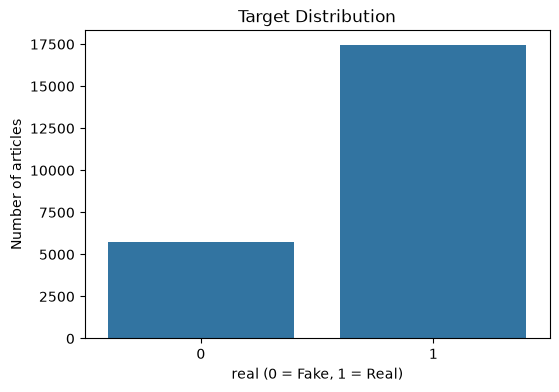

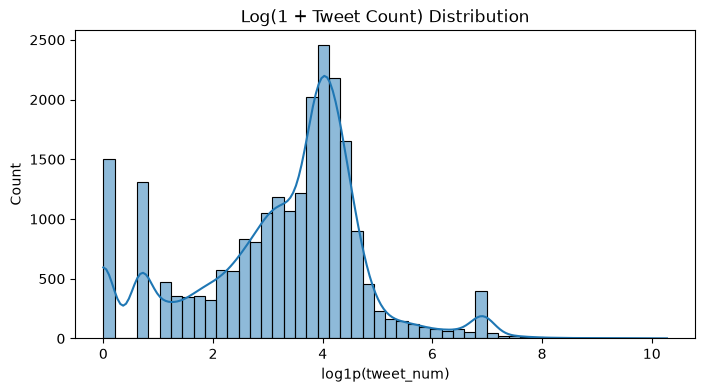

In [3]:
# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="real")
plt.title("Target Distribution")
plt.xlabel("real (0 = Fake, 1 = Real)")
plt.ylabel("Number of articles")
plt.show()

# Tweet count distribution
plt.figure(figsize=(8, 4))
sns.histplot(np.log1p(df["tweet_num"]), bins=50, kde=True)
plt.title("Log(1 + Tweet Count) Distribution")
plt.xlabel("log1p(tweet_num)")
plt.show()

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Fill missing values
df["title"] = df["title"].fillna("").astype(str)
df["source_domain"] = df["source_domain"].fillna("unknown").astype(str).str.lower().str.strip()
df["tweet_num"] = pd.to_numeric(df["tweet_num"], errors="coerce").fillna(0)
df["real"] = pd.to_numeric(df["real"], errors="coerce")

df = df[df["real"].isin([0, 1])].copy()
df["title_clean"] = df["title"].apply(clean_text)

# Remove exact duplicate records
before = len(df)
df = df.drop_duplicates(subset=["title_clean", "source_domain", "tweet_num", "real"]).reset_index(drop=True)
print("Removed duplicates:", before - len(df))
print("Final rows:", len(df))

Removed duplicates: 169
Final rows: 23027


## Train/test split

We use a **stratified 80/20 split** so the class ratio is preserved in both sets.

The test set is kept untouched until final evaluation.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df[["title_clean", "source_domain", "tweet_num"]],
    df["real"],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["real"]
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)
print("\nTrain label ratio:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nTest label ratio:")
print(y_test.value_counts(normalize=True).sort_index())

Train: (18421, 3)
Test : (4606, 3)

Train label ratio:
real
0    0.244992
1    0.755008
Name: proportion, dtype: float64

Test label ratio:
real
0    0.245115
1    0.754885
Name: proportion, dtype: float64


In [6]:
word_vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    strip_accents="unicode",
    min_df=2,
    max_df=0.98,
    ngram_range=(1, 2),
    max_features=120000
)

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    sublinear_tf=True,
    min_df=2,
    max_features=100000,
    ngram_range=(3, 5)
)

domain_encoder = OneHotEncoder(
    handle_unknown="ignore"
)

X_train_word = word_vectorizer.fit_transform(X_train["title_clean"])
X_test_word = word_vectorizer.transform(X_test["title_clean"])

X_train_char = char_vectorizer.fit_transform(X_train["title_clean"])
X_test_char = char_vectorizer.transform(X_test["title_clean"])

X_train_domain = domain_encoder.fit_transform(X_train[["source_domain"]])
X_test_domain = domain_encoder.transform(X_test[["source_domain"]])

# Scale log tweet count without centering because the final matrix is sparse
tweet_scaler = StandardScaler()
train_tweets = tweet_scaler.fit_transform(np.log1p(X_train[["tweet_num"]]))
test_tweets = tweet_scaler.transform(np.log1p(X_test[["tweet_num"]]))

X_train_final = hstack([
    X_train_word,
    X_train_char,
    X_train_domain,
    csr_matrix(train_tweets)
]).tocsr()

X_test_final = hstack([
    X_test_word,
    X_test_char,
    X_test_domain,
    csr_matrix(test_tweets)
]).tocsr()

print("Word features :", X_train_word.shape[1])
print("Char features :", X_train_char.shape[1])
print("Domain features:", X_train_domain.shape[1])
print("Final matrix  :", X_train_final.shape)

Word features : 29848
Char features : 100000
Domain features: 2154
Final matrix  : (18421, 132003)


## Train the classifier

`class_weight="balanced"` compensates for the fact that the dataset has substantially more real than fake examples.

In [7]:
model = LogisticRegression(
    C=2.0,
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
    random_state=RANDOM_STATE
)

model.fit(X_train_final, y_train)

y_pred = model.predict(X_test_final)
y_prob = model.predict_proba(X_test_final)[:, 1]

print("Model training complete.")

Model training complete.


In [8]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        balanced_acc,
        precision,
        recall,
        f1,
        auc
    ]
})

display(results.style.format({"Score": "{:.4f}"}))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fake", "Real"],
    digits=4
))

,Metric,Score
0,Accuracy,0.8567
1,Balanced Accuracy,0.8160
2,Precision,0.9127
3,Recall,0.8959
4,F1 Score,0.9042
5,ROC-AUC,0.9033



Classification Report:
              precision    recall  f1-score   support

        Fake     0.6966    0.7360    0.7158      1129
        Real     0.9127    0.8959    0.9042      3477

    accuracy                         0.8567      4606
   macro avg     0.8046    0.8160    0.8100      4606
weighted avg     0.8597    0.8567    0.8580      4606



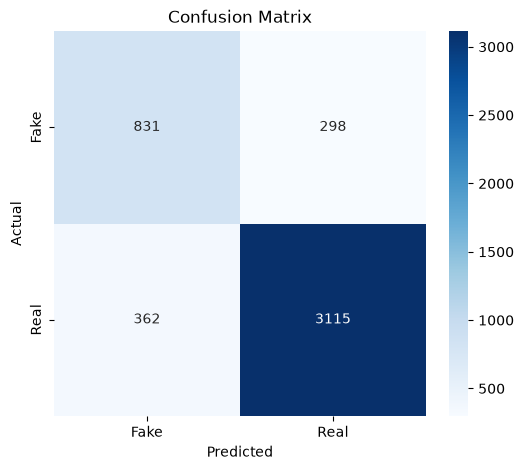

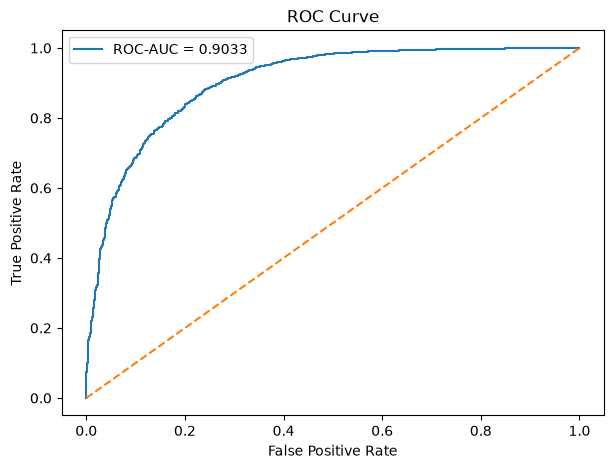

In [9]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Inspect model behaviour

For text models, examining influential words/phrases is useful for debugging.

These are **correlations learned from this dataset**, not proof that a word itself makes a news article fake or real.

In [10]:
# Inspect strongest word-level coefficients
word_features = word_vectorizer.get_feature_names_out()
word_coefs = model.coef_[0][:len(word_features)]

coef_df = pd.DataFrame({
    "feature": word_features,
    "coefficient": word_coefs
}).sort_values("coefficient")

print("Features associated with class 0 (Fake):")
display(coef_df.head(20))

print("Features associated with class 1 (Real):")
display(coef_df.tail(20).sort_values("coefficient", ascending=False))

Features associated with class 0 (Fake):


,feature,coefficient
27355,trump,-3.654180
4299,breaking,-3.262571
20908,react,-2.684103
19898,pitt,-2.430372
4240,brad,-2.382811
4245,brad pitt,-2.365832
4741,caitlyn,-2.359031
5219,celebrities,-2.319557
14406,kanye,-2.176966
8825,fake,-2.132197


Features associated with class 1 (Real):


,feature,coefficient
3593,best,1.847702
12395,how,1.844140
22469,season,1.710294
18448,of prince,1.608275
24155,star,1.568754
4946,cardi,1.552808
2879,awards,1.529313
27451,tv,1.439569
2971,baby no,1.338214
4962,care,1.280354


In [11]:
def predict_news(title, news_url="", source_domain="", tweet_num=0):
    title = "" if title is None else str(title)
    source_domain = "unknown" if source_domain is None or str(source_domain).strip() == "" else str(source_domain).lower().strip()

    title_clean = clean_text(title)
    tweet_num = max(0, float(tweet_num))

    word = word_vectorizer.transform([title_clean])
    char = char_vectorizer.transform([title_clean])
    domain = domain_encoder.transform([[source_domain]])
    tweet = tweet_scaler.transform(np.log1p([[tweet_num]]))

    features = hstack([
        word,
        char,
        domain,
        csr_matrix(tweet)
    ]).tocsr()

    probability_real = float(model.predict_proba(features)[0, 1])
    prediction = "REAL" if probability_real >= 0.5 else "FAKE"

    confidence = probability_real if prediction == "REAL" else 1 - probability_real

    return {
        "prediction": prediction,
        "probability_real": round(probability_real, 4),
        "probability_fake": round(1 - probability_real, 4),
        "confidence": round(confidence, 4)
    }

# Example
predict_news(
    title="Scientists announce a new breakthrough in renewable energy",
    source_domain="example.com",
    tweet_num=100
)

{'prediction': 'REAL',
 'probability_real': 0.8527,
 'probability_fake': 0.1473,
 'confidence': 0.8527}

In [ ]:
artifacts = {
    "model": model,
    "word_vectorizer": word_vectorizer,
    "char_vectorizer": char_vectorizer,
    "domain_encoder": domain_encoder,
    "tweet_scaler": tweet_scaler
}

joblib.dump(artifacts, "../models/fake_news_detector.joblib")

print("Saved: ../models/fake_news_detector.joblib")


```python
artifacts = joblib.load("fake_news_detector.joblib")

model = artifacts["model"]
word_vectorizer = artifacts["word_vectorizer"]
char_vectorizer = artifacts["char_vectorizer"]
domain_encoder = artifacts["domain_encoder"]
tweet_scaler = artifacts["tweet_scaler"]
clean_text = artifacts["clean_text"]
```

